<a href="https://colab.research.google.com/github/VaishnaviGumpi/AI-ML/blob/LAB/labexam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()


Saving auxiliary_metadata.json to auxiliary_metadata.json
Saving zoo.csv to zoo.csv
Saving class.csv to class.csv


In [30]:
def Delta_load_and_integrate():
    import pandas as pd
    import json

    # -----------------------------
    # A) LOAD ALL THREE DATASETS
    # -----------------------------

    zoo = pd.read_csv('zoo.csv', encoding='utf-8')
    classes = pd.read_csv('class.csv', encoding='utf-8')

    with open('auxiliary_metadata.json', 'r', encoding='utf-8') as f:
        metadata = json.load(f)

    meta_df = pd.DataFrame(metadata)

    # -----------------------------
    # B) CLEANING + NORMALIZATION
    # -----------------------------

    # Convert animal names to UPPERCASE (and KEEP them uppercase)
    if 'animal_name' in zoo.columns:
        zoo['animal_name'] = zoo['animal_name'].astype(str).str.upper()

    if 'animal_name' in meta_df.columns:
        meta_df['animal_name'] = meta_df['animal_name'].astype(str).str.upper()

    # Normalize column names (only column names, not values)
    zoo.columns = zoo.columns.str.strip().str.lower()
    classes.columns = classes.columns.str.strip().str.lower()
    meta_df.columns = meta_df.columns.str.strip().str.lower()

    # Clean text columns BUT DO NOT lowercase any values
    for df in [zoo, classes, meta_df]:
        for col in df.columns:
            if df[col].dtype == object:
                df[col] = df[col].astype(str).str.strip()

    # -----------------------------
    # C) MERGE DATASETS
    # -----------------------------

    # Merge zoo + class.csv
    if 'class_type' in zoo.columns and 'class_number' in classes.columns:
        merged = zoo.merge(classes, left_on='class_type', right_on='class_number', how='left')
    else:
        merged = zoo.copy()

    # Merge with metadata.json on ANIMAL_NAME
    final_df = merged.merge(meta_df, on='animal_name', how='left')

    return zoo, classes, meta_df, final_df


In [31]:
zoo, classes, meta_df, final_df = Delta_load_and_integrate()


In [32]:
zoo.head()



,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,breathes,venomous,fins,legs,tail,domestic,catsize,class_type
0,AARDVARK,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
1,ANTELOPE,1,0,0,1,0,0,0,1,1,1,0,0,4,1,0,1,1
2,BASS,0,0,1,0,0,1,1,1,1,0,0,1,0,1,0,0,4
3,BEAR,1,0,0,1,0,0,1,1,1,1,0,0,4,0,0,1,1
4,BOAR,1,0,0,1,0,0,1,1,1,1,0,0,4,1,0,1,1


In [33]:
classes.head()


,class_number,number_of_animal_species_in_class,class_type,animal_names
0,1,41,Mammal,"aardvark, antelope, bear, boar, buffalo, calf,..."
1,2,20,Bird,"chicken, crow, dove, duck, flamingo, gull, haw..."
2,3,5,Reptile,"pitviper, seasnake, slowworm, tortoise, tuatara"
3,4,13,Fish,"bass, carp, catfish, chub, dogfish, haddock, h..."
4,5,4,Amphibian,"frog, frog, newt, toad"


In [34]:
meta_df.head()


,animal_name,habitat,diet,conservation_status,conservation,habitats,status,diet_type
0,AARDVARK,savanna,insectivore,least concern,nan,nan,nan,nan
1,ANTELOPE,grasslands,herbivore,nan,near threatened,nan,nan,nan
2,BASS,freshwater,carnivore,least,nan,nan,nan,nan
3,BEAR,nan,omnivore,vulnerable,nan,forest,nan,nan
4,BOAR,forest,omnivor,nan,nan,nan,least concern,nan


In [35]:
zoo[['animal_name']].head()


,animal_name
0,AARDVARK
1,ANTELOPE
2,BASS
3,BEAR
4,BOAR


In [36]:
# --- Standardize column names ---
meta_df.columns = meta_df.columns.str.strip().str.lower()

# Fix field-name inconsistencies
if 'conservation' in meta_df.columns:
    meta_df.rename(columns={'conservation': 'conservation_status'}, inplace=True)

if 'status' in meta_df.columns:
    meta_df.rename(columns={'status': 'conservation_status'}, inplace=True)

if 'habitats' in meta_df.columns:
    meta_df.rename(columns={'habitats': 'habitat'}, inplace=True)

if 'diet_type' in meta_df.columns:
    meta_df.rename(columns={'diet_type': 'diet'}, inplace=True)

# --- Fix typos in diet column ---
if 'diet' in meta_df.columns:
    meta_df['diet'] = meta_df['diet'].str.lower().str.strip()

    meta_df['diet'] = meta_df['diet'].replace({
        'omnivor': 'omnivore',
        'carnivor': 'carnivore',
        'herbivor': 'herbivore'
    })

# --- Standardize habitat entries ---
if 'habitat' in meta_df.columns:
    meta_df['habitat'] = meta_df['habitat'].str.lower().str.strip()

    meta_df['habitat'] = meta_df['habitat'].replace({
        'fresh water': 'freshwater',
        'fresh water ': 'freshwater',
        'freshwater ': 'freshwater',
        'FreshWater'.lower(): 'freshwater',
        'marine/coastal': 'mixed',
        'Forest'.lower(): 'forest',
        'grasslands ': 'grasslands'
    })

# Final check
meta_df.head()


AttributeError: 'DataFrame' object has no attribute 'str'

In [63]:
df['habitat'] = df['habitat'].astype(str).str.lower().str.strip()

df['ecosystem_type'] = df['habitat'].replace({
    'savanna': 0,
    'grasslands': 0,
    'forest': 0,
    'domestic': 0,
    'freshwater': 1,
    'marine': 2,
    'mixed': 3
})

# default to terrestrial (0) if unknown
df['ecosystem_type'] = df['ecosystem_type'].fillna(0)


AttributeError: 'DataFrame' object has no attribute 'str'

In [37]:
# Always left merge to keep all zoo animals
merged = zoo.merge(meta_df, on='animal_name', how='left')

merged.head()


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,...,domestic,catsize,class_type,habitat,diet,conservation_status,conservation_status,habitat,conservation_status,diet
0,AARDVARK,1,0,0,1,0,0,1,1,1,...,0,1,1,savanna,insectivore,least concern,nan,nan,nan,nan
1,ANTELOPE,1,0,0,1,0,0,0,1,1,...,0,1,1,grasslands,herbivore,nan,near threatened,nan,nan,nan
2,BASS,0,0,1,0,0,1,1,1,1,...,0,0,4,freshwater,carnivore,least,nan,nan,nan,nan
3,BEAR,1,0,0,1,0,0,1,1,1,...,0,1,1,nan,omnivore,vulnerable,nan,forest,nan,nan
4,BOAR,1,0,0,1,0,0,1,1,1,...,0,1,1,forest,omnivor,nan,nan,nan,least concern,nan


In [62]:
df = merged.copy()




In [39]:
# --- ECOSYSTEM TYPE ---
merged['ecosystem_type'] = merged['habitat'].replace({
    'savanna': 0,
    'grasslands': 0,
    'forest': 0,
    'domestic': 0,
    'marine': 2,
    'freshwater': 1,
    'mixed': 3
}).fillna(0)  # default terrestrial

# --- PREDATOR SCORE ---
merged['diet'] = merged['diet'].astype(str).str.lower()

merged['predator_score'] = merged['diet'].replace({
    'carnivore': 3,
    'omnivore': 2,
    'herbivore': 1,
    'filter_feeder': 1,
    'insectivore': 1,
    'unknown': 1
})


ValueError: Cannot set a DataFrame with multiple columns to the single column ecosystem_type

In [40]:
merged.head()


,animal_name,hair,feathers,eggs,milk,airborne,aquatic,predator,toothed,backbone,...,domestic,catsize,class_type,habitat,diet,conservation_status,conservation_status,habitat,conservation_status,diet
0,AARDVARK,1,0,0,1,0,0,1,1,1,...,0,1,1,savanna,insectivore,least concern,nan,nan,nan,nan
1,ANTELOPE,1,0,0,1,0,0,0,1,1,...,0,1,1,grasslands,herbivore,nan,near threatened,nan,nan,nan
2,BASS,0,0,1,0,0,1,1,1,1,...,0,0,4,freshwater,carnivore,least,nan,nan,nan,nan
3,BEAR,1,0,0,1,0,0,1,1,1,...,0,1,1,nan,omnivore,vulnerable,nan,forest,nan,nan
4,BOAR,1,0,0,1,0,0,1,1,1,...,0,1,1,forest,omnivor,nan,nan,nan,least concern,nan


In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from pandas.plotting import scatter_matrix


In [42]:
def delta_eda_and_cleaning(df):

    print("===== EDA STARTED =====\n")

    # ------------------------------------
    # A1) HORIZONTAL BAR CHART OF CLASSES
    # ------------------------------------
    plt.figure(figsize=(10,6))
    class_counts = df['class_type'].value_counts()
    class_percent = (class_counts / len(df)) * 100

    sns.barplot(
        x=class_percent.values,
        y=class_percent.index,
        orient='h',
        palette='viridis'
    )

    plt.title("Class Distribution (%)")
    plt.xlabel("Percentage")
    plt.ylabel("Class Type")
    plt.show()

    # ------------------------------------
    # A2) BOX PLOT OF ENGINEERED FEATURES vs CLASSES
    # ------------------------------------
    if 'ecosystem_type' in df.columns and 'predator_score' in df.columns:
        fig, axes = plt.subplots(1, 2, figsize=(14,5))

        sns.boxplot(x='class_type', y='ecosystem_type', data=df, ax=axes[0])
        axes[0].set_title("Ecosystem Type vs Class")

        sns.boxplot(x='class_type', y='predator_score', data=df, ax=axes[1])
        axes[1].set_title("Predator Score vs Class")

        plt.tight_layout()
        plt.show()
    else:
        print("Engineered features missing. Skipping boxplots.")

    # ------------------------------------
    # A3) SCATTER PLOT MATRIX (diet vs features)
    # ------------------------------------
    if {'diet','ecosystem_type','predator_score'}.issubset(df.columns):

        df_scatter = df[['ecosystem_type','predator_score']].copy()
        df_scatter['diet'] = df['diet']

        scatter_matrix(df_scatter, figsize=(8,8), diagonal='hist')
        plt.suptitle("Scatter Matrix: Diet vs Engineered Features")
        plt.show()

    else:
        print("Missing scatter matrix columns. Skipping.")

    # ------------------------------------
    # A4) CORRELATION HEATMAP WITH CLUSTERING
    # ------------------------------------
    plt.figure(figsize=(10,7))
    corr = df.select_dtypes(include=[np.number]).corr()

    sns.clustermap(corr, annot=True, cmap='coolwarm')
    plt.title("Correlation Heatmap with Clustering")
    plt.show()

    # ------------------------------------
    # B) CLASS IMBALANCE RATIO
    # largest class size / smallest class size
    # ------------------------------------
    class_counts = df['class_type'].value_counts()
    imbalance_ratio = class_counts.max() / class_counts.min()

    print("\n===== CLASS BALANCE REPORT =====")
    print("Class Counts:")
    print(class_counts)
    print(f"\nClass Imbalance Ratio = {imbalance_ratio:.2f}")

    print("\n===== EDA COMPLETE =====")

    return imbalance_ratio


===== EDA STARTED =====



/tmp/ipython-input-1156536046.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


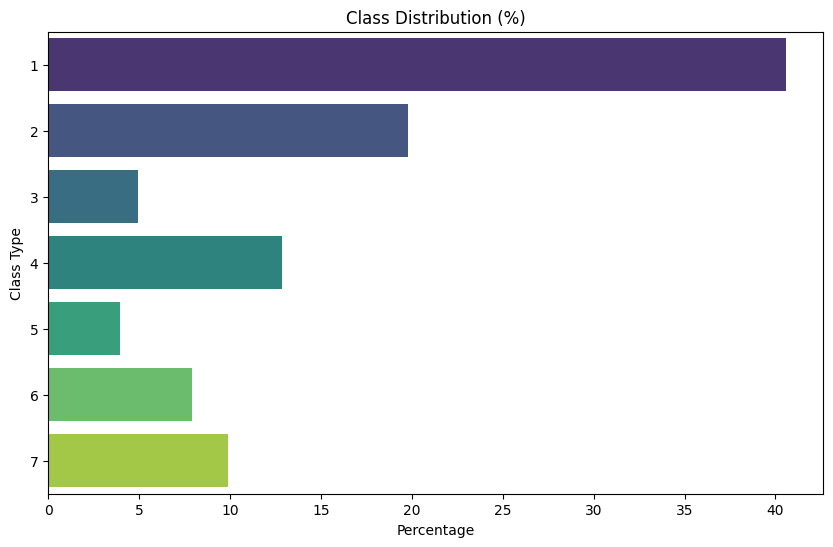

Engineered features missing. Skipping boxplots.
Missing scatter matrix columns. Skipping.


<Figure size 1000x700 with 0 Axes>

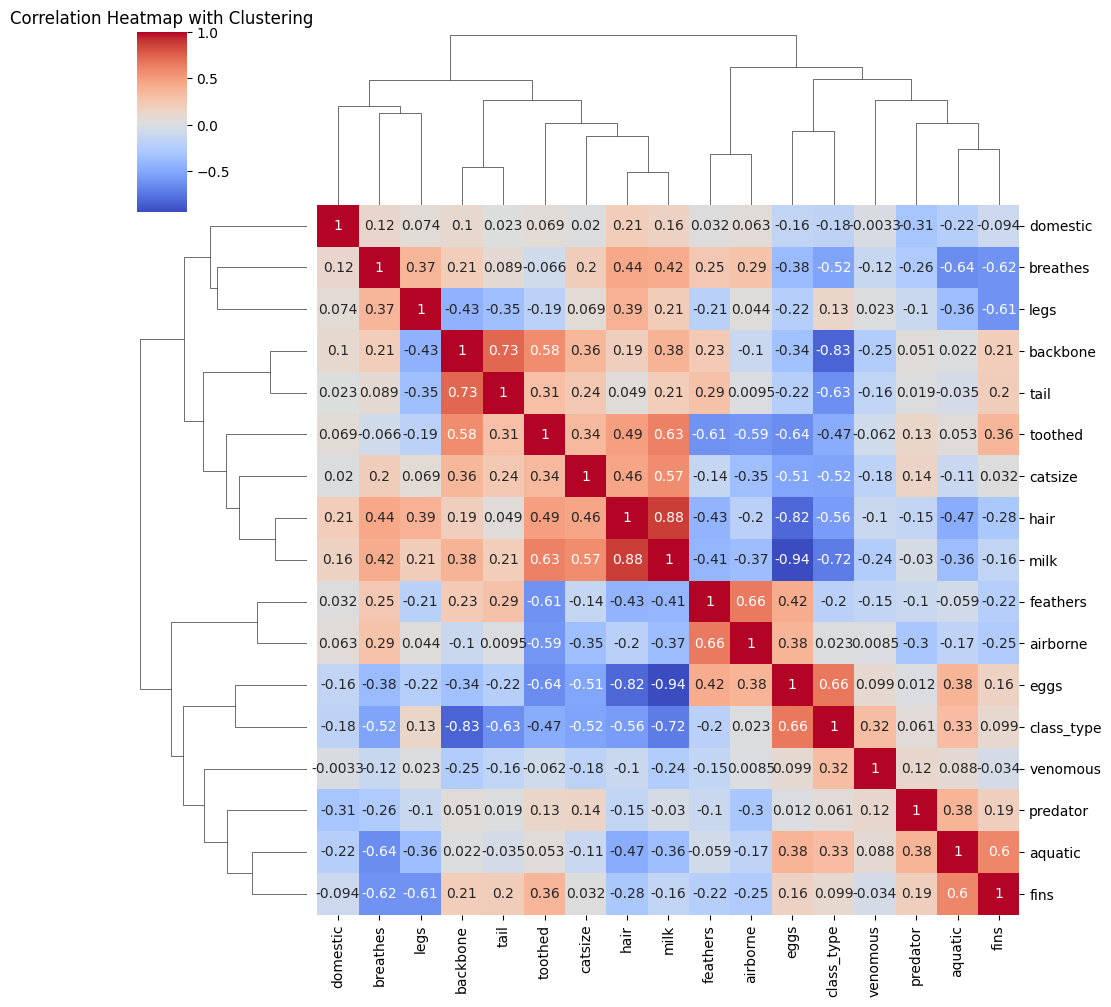


===== CLASS BALANCE REPORT =====
Class Counts:
class_type
1    41
2    20
4    13
7    10
6     8
3     5
5     4
Name: count, dtype: int64

Class Imbalance Ratio = 10.25

===== EDA COMPLETE =====


In [43]:
eda_ratio = delta_eda_and_cleaning(merged)


In [47]:
# CLASS IMBALANCE RATIO (largest class size / smallest class size)
class_sizes = merged['class_type'].value_counts()

imbalance_ratio = class_sizes.max() / class_sizes.min()

print("Class Counts:\n", class_sizes)
print(f"\nClass Imbalance Ratio = {imbalance_ratio:.2f}")


Class Counts:
 class_type
1    41
2    20
4    13
7    10
6     8
3     5
5     4
Name: count, dtype: int64

Class Imbalance Ratio = 10.25


In [48]:
# Selecting only numeric features
numeric_cols = merged.select_dtypes(include=[np.number])

# Compute variance
variances = numeric_cols.var()

# Filter features with variance < 0.01
low_variance_features = variances[variances < 0.01]

print("LOW VARIANCE FEATURES (<0.01):")
print(low_variance_features)


LOW VARIANCE FEATURES (<0.01):
Series([], dtype: float64)


In [49]:
corr_matrix = numeric_cols.corr().abs()

# Get upper triangle mask
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_pairs = [
    (col1, col2, upper_triangle.loc[col1, col2])
    for col1 in upper_triangle.columns
    for col2 in upper_triangle.columns
    if pd.notna(upper_triangle.loc[col1, col2]) and upper_triangle.loc[col1, col2] > 0.8
]

print("HIGHLY CORRELATED PAIRS (|corr| > 0.8):")
for p in high_corr_pairs:
    print(p)


HIGHLY CORRELATED PAIRS (|corr| > 0.8):
('hair', 'eggs', np.float64(0.8173815452256148))
('hair', 'milk', np.float64(0.8785027248895131))
('eggs', 'milk', np.float64(0.9388478737749794))
('backbone', 'class_type', np.float64(0.8288452641993185))


In [50]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [51]:
df = merged.copy()

# One-hot encode diet (if present)
if 'diet' in df.columns:
    df = pd.get_dummies(df, columns=['diet'], drop_first=True)

# Drop non-numeric or irrelevant features for ML
drop_cols = ['animal_name', 'habitat', 'conservation_status']
df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors='ignore')

# Split features & target
X = df.drop('class_type', axis=1)
y = df['class_type']


In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    train_size=0.75,
    random_state=123,
    stratify=y
)


In [53]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [54]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=123
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


In [55]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=123
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)


In [56]:
print("===== RANDOM FOREST PERFORMANCE =====")
print(classification_report(y_test, rf_pred, digits=3))


===== RANDOM FOREST PERFORMANCE =====
              precision    recall  f1-score   support

           1      1.000     1.000     1.000        11
           2      0.833     1.000     0.909         5
           3      0.000     0.000     0.000         1
           4      1.000     1.000     1.000         3
           5      1.000     1.000     1.000         1
           6      1.000     1.000     1.000         2
           7      1.000     1.000     1.000         3

    accuracy                          0.962        26
   macro avg      0.833     0.857     0.844        26
weighted avg      0.929     0.962     0.944        26



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


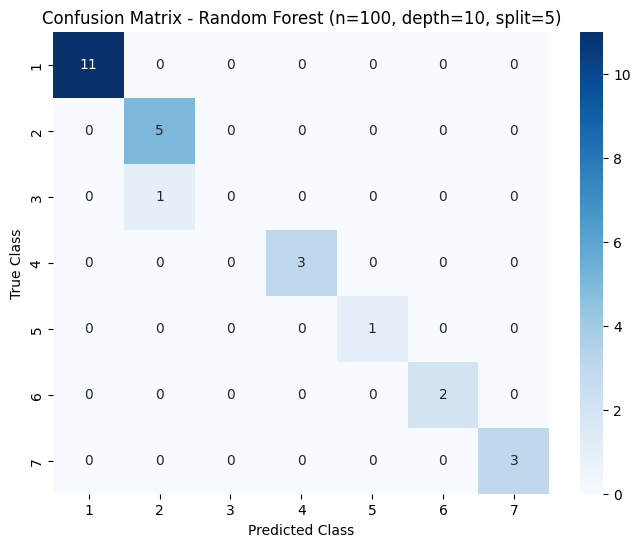

In [57]:
cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sorted(y.unique()),
            yticklabels=sorted(y.unique()))
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix - Random Forest (n=100, depth=10, split=5)")
plt.show()


In [58]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)

print("===== KNN (k=5) PERFORMANCE =====")
print(classification_report(y_test, knn_pred, digits=3))


===== KNN (k=5) PERFORMANCE =====
              precision    recall  f1-score   support

           1      1.000     1.000     1.000        11
           2      0.833     1.000     0.909         5
           3      0.000     0.000     0.000         1
           4      1.000     1.000     1.000         3
           5      1.000     1.000     1.000         1
           6      1.000     1.000     1.000         2
           7      1.000     0.667     0.800         3

    accuracy                          0.923        26
   macro avg      0.833     0.810     0.816        26
weighted avg      0.929     0.923     0.921        26



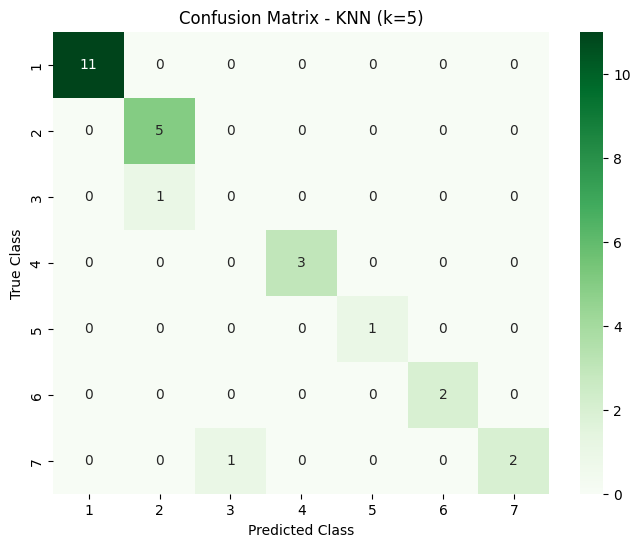

In [59]:
cm_knn = confusion_matrix(y_test, knn_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens',
            xticklabels=sorted(y.unique()),
            yticklabels=sorted(y.unique()))
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix - KNN (k=5)")
plt.show()
